# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 8: *Evaluation and Visualization*
##### Version Number: 3.0
---
### Contents  
> 1. *Build Models*
> 2. *Train Models*
> 3. *Generate Predictions*
> 4. *Geospatial Visualization*
> 5. *Export File*
---
### Notes
This section applies the trained models to predict wildfire severity in real-world scenarios including
- #### Palisades Fire (January 07, 2025)  

It evaluates and compare the performance of three classification models:
- **XGBoost**
- **Random Forest**
- **Neural Network**
---
### Inputs
- `X.csv` Model data
- `y.csv` Target data
- `details.csv` details reguarding data
- `pal_X`,`pal_details` data for 2025 predictions
- `best_strategy` best class balancing strategies calculated from module 06
- `model_parameters` optimum parameters as determined by module 07

---
### Outputs  
- `predictions.csv` Dataset containing prediction models composed of a categorical prediction 0,1,2 to be used for interpolation in ArcGIS.
---
### User Created Dependencies  

In [1]:
# Add the parent directory to the system path so "src" can be found
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# user built utilities
from src.plot_utils import plot_map

from src.model_utils import apply_balancing

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import RidgeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMClassifier

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point

from datetime import timedelta
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

---
### Global Constants

In [3]:
# first day to analyze in weather dataset
FIRST_DATE = pd.to_datetime('2018-01-01').date()

# last day to analyze in weather dataset
LAST_DATE = pd.to_datetime('2024-12-31').date()

---

### Load Data

In [4]:
X = pd.read_csv('../data/processed/X_scaled.csv')
y = pd.read_csv('../data/processed/y_reduced.csv').squeeze()  # Load as Series
details = pd.read_csv('../data/processed/details.csv')

best_strategy = pd.read_csv('../data/processed/best_strategy.csv')
model_parameters = pd.read_csv('../data/processed/model_parameters.csv', index_col=0)

In [5]:
pal_details = pd.read_csv('../data/processed/pal_details.csv')
pal_X = pd.read_csv('../data/processed/pal_X.csv')
pal_y = pd.read_csv('../data/processed/pal_y.csv')

pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date
details['Date'] = pd.to_datetime(details['Date']).dt.date

In [6]:
#pal_X = pal_X.drop(columns = 'Year')

In [7]:
scaler = MinMaxScaler()
pal_X_scaled = scaler.fit_transform(pal_X)
pal_X_scaled = pd.DataFrame(
    pal_X_scaled,
    columns=pal_X.columns,
    index=pal_X.index
)
pal_X = pal_X_scaled

In [8]:
pal_X['Target'] = pal_y
X['Target'] = y

In [9]:
y.value_counts()

Target
0    10000
1    10000
2    10000
Name: count, dtype: int64

## 1. Build Models

In [10]:
model_parameters = pd.read_csv('../data/processed/model_parameters.csv', index_col=0)

In [11]:
RF_parameters = model_parameters.loc['RandomForest'].dropna().to_dict()
XGB_parameters = model_parameters.loc['XGBoost'].dropna().to_dict()
LGBM_parameters = model_parameters.loc['LGBM'].dropna().to_dict()

optimal_learning_rate = XGB_parameters['learning_rate']
optimal_learning_rate_lgbm = LGBM_parameters['learning_rate']


In [12]:
# Helper function to convert to int if possible
def convert_to_int(d):
    return {k: int(float(v)) if str(v).replace('.', '', 1).isdigit() else v for k, v in d.items()}

RF_parameters = convert_to_int(RF_parameters)
XGB_parameters = convert_to_int(XGB_parameters)
LGBM_parameters = convert_to_int(LGBM_parameters)

XGB_parameters['learning_rate'] = optimal_learning_rate
LGBM_parameters['learning_rate'] = optimal_learning_rate_lgbm
LGBM_parameters['verbose'] = -1

In [13]:
display(RF_parameters)
display(XGB_parameters)
display(LGBM_parameters)

{'n_estimators': 50,
 'max_depth': 20,
 'min_samples_split': 20,
 'max_features': 'sqrt',
 'class_weight': 'balanced'}

{'n_estimators': 150,
 'max_depth': 6,
 'objective': 'multi:softmax',
 'num_class': 3,
 'learning_rate': 0.1,
 'verbosity': 0}

{'n_estimators': 150,
 'max_depth': 7,
 'class_weight': 'balanced',
 'learning_rate': 0.1,
 'num_leaves': 127,
 'verbose': -1}

In [14]:
# Build Final tuned models
optimum_xgb_model = xgb.XGBClassifier(**XGB_parameters)
optimum_rf = RandomForestClassifier(**RF_parameters)
optimum_lgbm_model = LGBMClassifier(**LGBM_parameters)

## 2. Train Models

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

In [16]:
X_train_balanced, y_train_balanced = apply_balancing('RF', best_strategy, X_train, y_train)
optimum_rf.fit(X_train_balanced, y_train_balanced)

X_train_balanced, y_train_balanced = apply_balancing('LGBM', best_strategy, X_train, y_train)
optimum_lgbm_model.fit(X_train_balanced, y_train_balanced)

X_train_balanced, y_train_balanced = apply_balancing('XGB', best_strategy, X_train, y_train)
optimum_xgb_model.set_params(verbosity=0)
optimum_xgb_model.fit(X_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [17]:
# Create a Series for easy sorting
importances = pd.Series(optimum_rf.feature_importances_, index=X.columns)

# Get top 10
top10 = importances.sort_values(ascending=False).head(10)

top10.to_frame(name="Random Forest Top 10 Importance")

,Random Forest Top 10 Importance
Target,0.532237
elevation_range,0.025999
slope_mean,0.025406
Month,0.023457
Season,0.022508
2-Year Avg Fires,0.021344
Year,0.015335
housing_density,0.012783
road_length_meters,0.012030
1000-hour Dead Fuel Moisture,0.011864


In [18]:
# Create a Series for easy sorting
importances = pd.Series(optimum_lgbm_model.feature_importances_, index=X.columns)

# Get top 10
top10 = importances.sort_values(ascending=False).head(10)

top10.to_frame(name="LGBM Top 10 Importance")

,LGBM Top 10 Importance
Burning Index,875
Target,626
Energy Release Component,283
Actual Evapotranspiration,231
100-hour Dead Fuel Moisture,123
elevation_range,103
1000-hour Dead Fuel Moisture,102
Maximum Relative Humidity,55
Specific Humidity,51
Precipitation,46


In [19]:
# Create a Series for easy sorting
importances = pd.Series( optimum_xgb_model.feature_importances_, index=X.columns)

# Get top 10
top10 = importances.sort_values(ascending=False).head(10)

top10.to_frame(name="XGB Top 10 Importance")

,XGB Top 10 Importance
Target,0.999619
total_population,0.000067
elevation_std,0.000053
2-Year Avg Fires,0.000031
population_density,0.000030
elevation_range,0.000029
total_housing,0.000027
power_line_density,0.000020
road_density,0.000019
interface_zone,0.000017


In [20]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"Evaluation for {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.3f}")
    print("---- Classification Report ----")
    print(classification_report(y_test, y_pred))
    print("\n")

In [21]:
evaluate_model(optimum_xgb_model, X_test, y_test, "XGBoost")

Evaluation for XGBoost
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
---- Classification Report ----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1986
           1       1.00      1.00      1.00      2052
           2       1.00      1.00      1.00      1962

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000





In [22]:
evaluate_model(optimum_rf, X_test, y_test, "Random Forest")

Evaluation for Random Forest
Accuracy:  0.999
Precision: 0.999
Recall:    0.999
F1 Score:  0.999
---- Classification Report ----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1986
           1       1.00      1.00      1.00      2052
           2       1.00      1.00      1.00      1962

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000





In [23]:
evaluate_model(optimum_lgbm_model, X_test, y_test, "LightGBM")

Evaluation for LightGBM
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
---- Classification Report ----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1986
           1       1.00      1.00      1.00      2052
           2       1.00      1.00      1.00      1962

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000





## 3. Generate Predictions

In [24]:
# Palisades Fire (January 2025)
pal_xgb_predictions = pd.DataFrame(optimum_xgb_model.predict(pal_X))
pal_xgb_predictions.value_counts()

0
0    4583
1     773
2      72
Name: count, dtype: int64

In [25]:
pal_rf_predictions = pd.DataFrame(optimum_rf.predict(pal_X))
pal_rf_predictions.value_counts()

0
0    4583
1     844
2       1
Name: count, dtype: int64

In [26]:
pal_lgbm_predictions = pd.DataFrame(optimum_lgbm_model.predict(pal_X))
pal_lgbm_predictions.value_counts()

0
0    4583
1     773
2      72
Name: count, dtype: int64

### 3.1 Save Predictions for plotting

In [27]:
pal_details = pal_details.copy()

pal_details['Prediction XGB'] = pal_xgb_predictions[0].values
pal_details['Prediction RF']  = pal_rf_predictions[0].values
pal_details['Prediction LGBM']  = pal_lgbm_predictions[0].values

pal_details['Prediction Actual'] = pal_y

In [28]:
pal_specific_date = pd.to_datetime('2025-01-08').date()
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

In [29]:
pal_details['geometry'] = [Point(xy) for xy in zip(pal_details ['centroid_easting'], pal_details ['centroid_northing'])]
pal_gdf = gpd.GeoDataFrame(pal_details , geometry='geometry', crs="EPSG:3310")

pal_gdf = pal_gdf.to_crs('4326')

In [30]:
pal_gdf['Longitude'] = pal_gdf.geometry.x
pal_gdf['Latitude'] = pal_gdf.geometry.y

In [31]:
pal_predictions = pal_gdf[pal_gdf['Date'] == pal_specific_date]

## 2 Geospatial Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025) and the Dixie Fire (July 2021).

### 2.1 Palisades Predictions 01072025

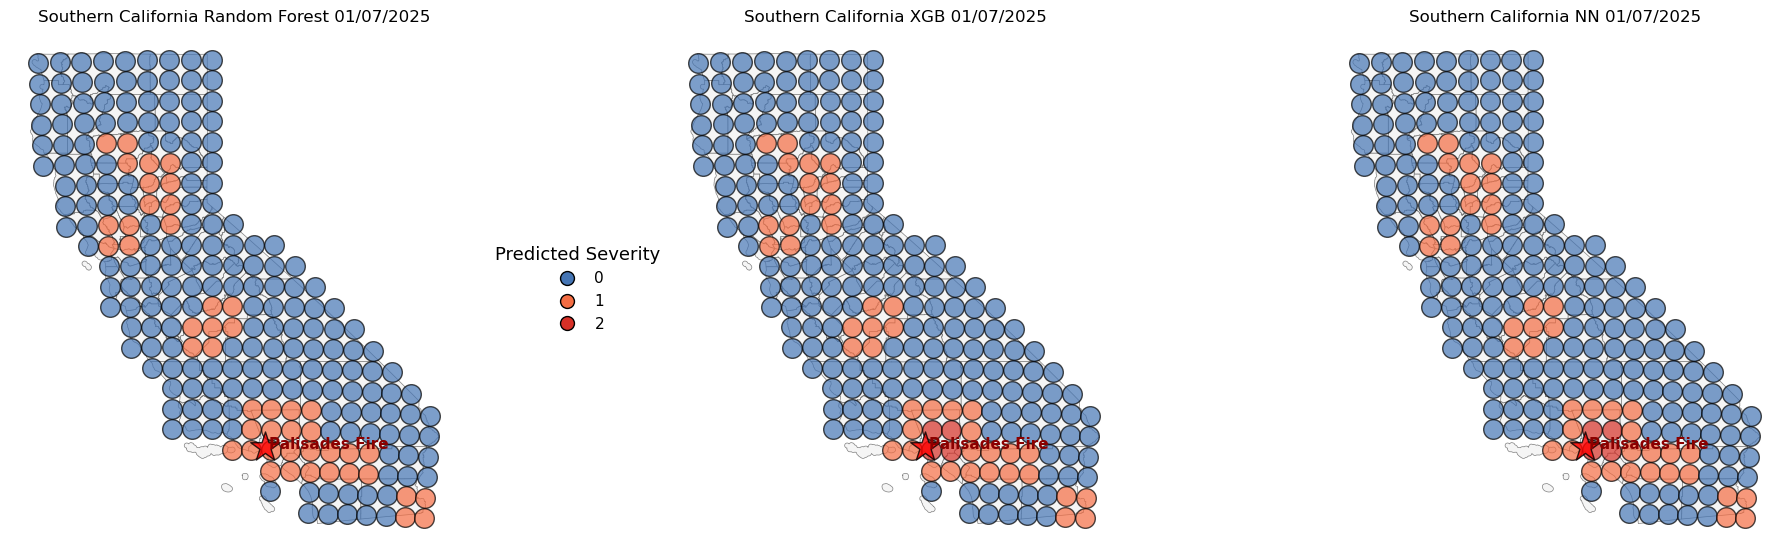

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_predictions, 'Prediction RF', 'Palisades', ax=axes[0])
plot_map(pal_predictions, 'Prediction XGB', 'Palisades', ax=axes[1])
plot_map(pal_predictions, 'Prediction LGBM', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California XGB 01/07/2025')
axes[2].set_title('Southern California NN 01/07/2025')

plt.tight_layout()

#plt.savefig("../plots/Palisades_predictions.png", dpi=600)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_predictions, 'Prediction Actual', 'Palisades', ax=axes[0])
plot_map(pal_predictions, 'Prediction Actual', 'Palisades', ax=axes[1])
plot_map(pal_predictions, 'Prediction Actual', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Actual 01/07/2025')
axes[1].set_title('Southern California Actual 01/07/2025')
axes[2].set_title('Southern California Actual 01/07/2025')

plt.tight_layout()

#plt.savefig("../plots/Palisades_predictions.png", dpi=600)

### Interpolation

<img src="../data/maps/IDW_RF.jpg" width="600">

## 3. Export File

In [ ]:
pal_gdf.to_csv('../data/processed/predictions.csv', index=False)